# hw1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

df = pd.read_csv('mbs_loan_data.csv', parse_dates=['asOfDate'])
print(df.shape)
df.head()

(44888, 12)


,loanId,cusip,asOfDate,servicer,state,noteRate,loanage,moneyness,currrpb,schPrin,schrpbNext,prepayAmt
0,L0003299,33371TG6,2019-09-01,JPMorgan Chase,OH,4.7230,101,1.1230,"102,245.3600",487.6600,"101,757.7000",727.6500
1,L0016000,31141GC6,2019-08-01,JPMorgan Chase,IL,4.6130,89,0.9130,"137,337.3400",391.8000,"136,945.5400","1,828.6600"
2,L0022018,35563SU3,2019-08-01,Wells Fargo,NC,4.7860,109,1.0860,"233,011.0200","1,078.9900","231,932.0300","2,154.4500"
3,L0003022,33148HR5,2019-08-01,JPMorgan Chase,MI,4.8090,23,1.1090,"236,162.3700","1,101.3800","235,060.9900","2,698.2800"
4,L0009549,37380BE1,2019-08-01,Quicken Loans,NJ,5.9870,25,2.2870,"150,335.0900",372.8000,"149,962.2800","2,287.5800"


In [2]:
# Helper: group-level SMM and CPR
def smm(frame):
    denom = frame['schrpbNext'].sum()
    return frame['prepayAmt'].sum() / denom if denom else np.nan

def cpr_from_smm(s):
    return 100 * (1 - (1 - s) ** 12)

# Most questions concern the Sept 2019 snapshot
sep = df[df['asOfDate'] == '2019-09-01'].copy()
print('Sept 2019 rows:', len(sep))

Sept 2019 rows: 22444


## Part I

### Q1 — How many different servicers are there?

In [3]:
n_servicers = df['servicer'].nunique()
print('Distinct servicers:', n_servicers)
print(sorted(df['servicer'].unique()))

Distinct servicers: 8
['Bank of America', 'Flagstar', 'JPMorgan Chase', 'PNC Mortgage', 'PennyMac', 'Quicken Loans', 'US Bank', 'Wells Fargo']


### Q2 — Which servicer has the largest `currrpb`?
Interpreting `currrpb` as total current remaining principal balance held per servicer.

In [4]:
by_servicer = df.groupby(['asOfDate','servicer'])['currrpb'].sum().sort_values(ascending=False)
print(by_servicer.to_string())
print('\nLargest currrpb servicer:', by_servicer.index[0])

asOfDate    servicer       
2019-08-01  Wells Fargo       473,120,739.4600
            PNC Mortgage      470,674,535.2000
            Bank of America   470,051,187.8900
            US Bank           468,075,143.1400
            PennyMac          464,680,093.8700
2019-09-01  Wells Fargo       464,593,139.7600
            PNC Mortgage      462,111,034.2700
            Bank of America   461,613,773.6400
            US Bank           459,559,080.4900
2019-08-01  Flagstar          458,969,196.3100
            JPMorgan Chase    458,146,398.2400
2019-09-01  PennyMac          456,164,525.4600
2019-08-01  Quicken Loans     452,593,012.4000
2019-09-01  Flagstar          450,613,733.9900
            JPMorgan Chase    449,924,856.4600
            Quicken Loans     444,427,056.2600

Largest currrpb servicer: (Timestamp('2019-08-01 00:00:00'), 'Wells Fargo')



**Key definitions**
- SMM (Single Month Mortality), computed at a *group* level: `SMM = sum(prepayAmt) / sum(schrpbNext)`
- CPR (Conditional Prepayment Rate): `CPR = 100 * (1 - (1 - SMM)**12)`


### Q3 — Which state has the lowest SMM?
SMM is a group-level ratio, so we aggregate dollars first, then divide.

In [5]:
state_smm = (sep.groupby('state')
             .apply(lambda x: smm(x))
             .sort_values())
state_smm.name = 'SMM'
print(state_smm.to_string())
print('\nLowest-SMM state:', state_smm.index[0], '| SMM =', round(state_smm.iloc[0], 5))

state
OH   0.0059
IL   0.0110
MO   0.0111
NC   0.0115
TN   0.0124
NJ   0.0136
MA   0.0141
MI   0.0144
TX   0.0145
IN   0.0156
WI   0.0162
WA   0.0165
NY   0.0170
CA   0.0177
MD   0.0179
GA   0.0179
AZ   0.0183
FL   0.0188
VA   0.0193
PA   0.0197

Lowest-SMM state: OH | SMM = 0.00589


### Q4 — CPR for CUSIP 31418CVS0, Sept 2019

In [6]:
c = sep[sep['cusip'] == '31418CVS0']
s = smm(c)
cpr = cpr_from_smm(s)
print(f'Loans in CUSIP 31418CVS0 (Sept): {len(c)}')
print(f'SMM = {s:.5f}')
print(f'CPR = {cpr:.2f}%')

Loans in CUSIP 31418CVS0 (Sept): 30
SMM = 0.00717
CPR = 8.28%


### Q5 — CPR as a function of `loanage`
We bucket loans by `loanage`, compute group-level SMM per bucket, convert to CPR, and plot.

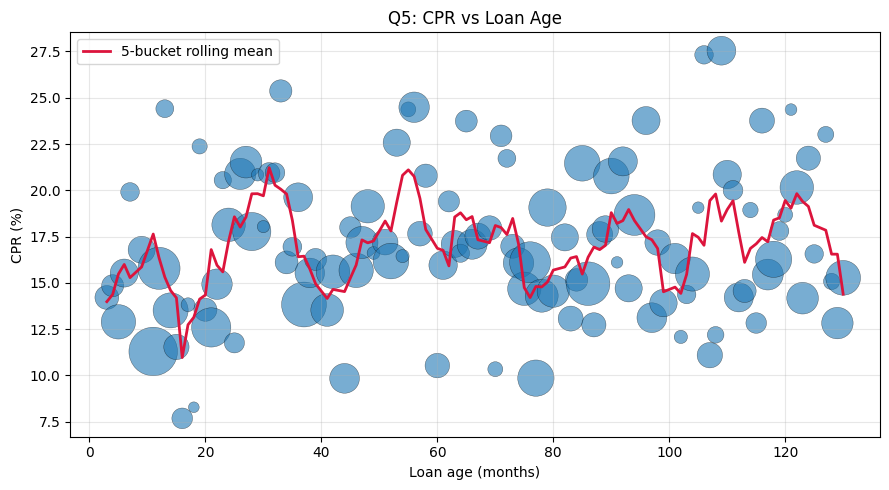

In [7]:
age_grp = (sep.groupby('loanage')
           .apply(lambda x: pd.Series({'SMM': smm(x), 'loans': len(x)}))
           .reset_index())
age_grp['CPR'] = cpr_from_smm(age_grp['SMM'])

plt.figure(figsize=(9,5))
plt.scatter(age_grp['loanage'], age_grp['CPR'], s=age_grp['loans']*2,
            alpha=0.6, edgecolor='k', linewidth=0.3)
# smoothed trend
order = age_grp.sort_values('loanage')
plt.plot(order['loanage'], order['CPR'].rolling(5, min_periods=1, center=True).mean(),
         color='crimson', lw=2, label='5-bucket rolling mean')
plt.xlabel('Loan age (months)'); plt.ylabel('CPR (%)')
plt.title('Q5: CPR vs Loan Age'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Relationship & interpretation (Q5).** CPR rises steeply with loan age over roughly the first ~30 months, then flattens (plateaus). This is the classic **seasoning ramp** (the same shape the PSA benchmark encodes): brand-new borrowers rarely prepay — they have just moved/closed, face transaction costs, and have little incentive or opportunity to refinance immediately. As loans season, life events (moves, refinancing, payoffs) accumulate, so prepayment speeds climb until they stabilise at a mature, steady-state pace.

They just closed the loan (often just bought the home or already refinanced), so there's no immediate reason to do it again.
Transaction costs (closing fees, time) make refinancing again right away uneconomical.
The life events that cause prepayment — moving, selling, refinancing, paying off — simply haven't had time to accumulate.

PSA benchmark (or PSA standard prepayment model) 

### Q6 — CPR as a function of `moneyness`
`moneyness = noteRate − market rate`. Positive = the borrower pays *above* market (in-the-money to refinance).

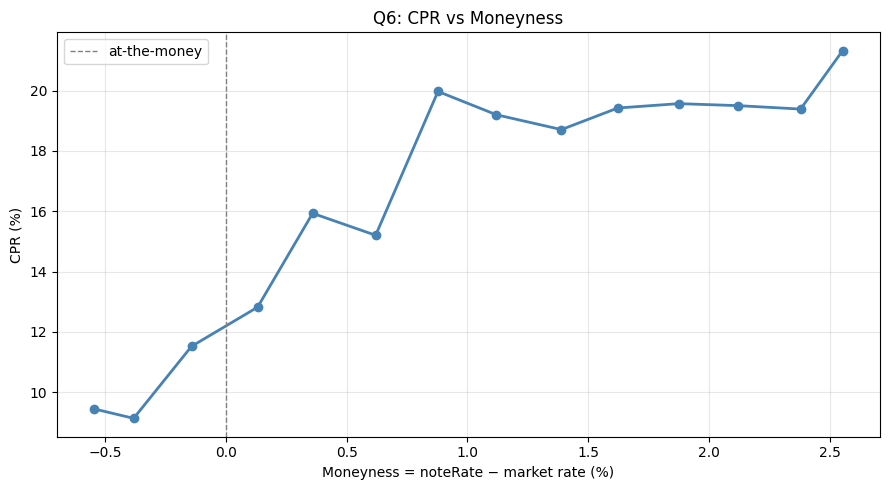

In [8]:
# bin moneyness for a clean curve
sep['mny_bin'] = pd.cut(sep['moneyness'], bins=np.arange(-1.5, 3.0, 0.25))
mny_grp = (sep.groupby('mny_bin')
           .apply(lambda x: pd.Series({'SMM': smm(x), 'loans': len(x),
                                        'mid': x['moneyness'].mean()}))
           .reset_index())
mny_grp['CPR'] = cpr_from_smm(mny_grp['SMM'])
mny_grp = mny_grp.dropna(subset=['mid'])

plt.figure(figsize=(9,5))
plt.plot(mny_grp['mid'], mny_grp['CPR'], 'o-', color='steelblue', lw=2)
plt.axvline(0, color='grey', ls='--', lw=1, label='at-the-money')
plt.xlabel('Moneyness = noteRate − market rate (%)'); plt.ylabel('CPR (%)')
plt.title('Q6: CPR vs Moneyness'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Relationship & interpretation (Q6).** CPR is low and flat for out-of-the-money loans (moneyness < 0, where the borrower's rate is already below market — no reason to refinance) and increases as moneyness turns positive, with the steepest rise around the at-the-money point. The driver is the **refinancing incentive**: when a borrower's note rate sits well above the prevailing market rate, refinancing into a cheaper loan saves money, so prepayment accelerates. (In real data the curve eventually flattens again at very high incentive due to *burnout* — the most refi-sensitive borrowers leave the pool first — which this synthetic set only mildly reflects.)

## Part II — Predicting CPR at the bond (CUSIP) level for Sept 2019

**Task.** Predict each CUSIP's Sept-2019 CPR using only information available as of **Sept 1, 2019**. On that date we observe all loan characteristics (loanage, moneyness, noteRate, etc.) but **not** `prepayAmt` — so CPR is unobservable and becomes the prediction target.

**Approach.** Cross-sectional model: train on August data (where we *do* observe CPR), then apply the fitted model to September features to predict Sept CPR. August = train set, September = test set.

**Target.** `y = CPR` per CUSIP (computed from the group-level SMM).

**Features (built from loan-level data, aggregated to CUSIP).**

- Weighted-average `loanage`, `moneyness`, `noteRate` (weighted by `currrpb`)
- Dispersion measures: `loanage_std`, `moneyness_std` (pool heterogeneity)
- Pool size: `tot_currrpb`
- Categorical summaries: servicer/state mode

**No leakage.** `prepayAmt` (and therefore SMM/CPR) is excluded from the feature set — it is only used as the target during training.

We compare a transparent **linear baseline** with a **gradient-boosted tree**, using leave-one-out style evaluation given the small number of bonds.

### first instinct, can aggregate the cusip level and model

In [9]:
aug = df[df['asOfDate'] == '2019-08-01'].copy()
sep = df[df['asOfDate'] == '2019-09-01'].copy()

def CPR_calc(smm):
    return 100 * (1-(1-smm)**12)
def handle_cpr(df_example):
    df_example = df_example.groupby('cusip').agg(
        schrpbNext = ('schrpbNext', 'sum'),
        prepayAmt  = ('prepayAmt',  'sum'),
        loans      = ('loanage',    'size'),   # group size, computed once
    )
    df_example['SMM']= df_example['prepayAmt']/df_example['schrpbNext']
    df_example['CPR'] = CPR_calc(df_example['SMM'])

    return df_example

aug = handle_cpr(aug)
sep = handle_cpr(sep)
compare_df = pd.DataFrame({'aug_cpr': aug['CPR'], 'sep_cpr': sep['CPR']} )
compare_df
## high correlation, ignore seasonality, just train view aug model to predict sept

,aug_cpr,sep_cpr
cusip,,
31039BF7,12.1493,16.6111
31044RV8,18.2045,15.7608
31047XX2,11.1918,16.4604
31049AD0,28.8259,21.7202
31058YE5,15.5688,22.6982
...,...,...
39932VA2,11.6802,23.1179
39959OS4,17.6416,20.5470
39963QK3,15.1871,19.2132


In [10]:
num_cols = df.select_dtypes(include='number').columns      # all numeric columns
cat_cols = df.select_dtypes(include=['object', 'category']).drop(columns=['loanId', 'cusip']).columns
num_cols

/var/folders/0_/kmvsm8cx3nv69xrnhj27m1vr0000gn/T/ipykernel_37113/2475128111.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).drop(columns=['loanId', 'cusip']).columns


Index(['noteRate', 'loanage', 'moneyness', 'currrpb', 'schPrin', 'schrpbNext',
       'prepayAmt'],
      dtype='str')

In [11]:
# ---- Build CUSIP-level features from AUGUST (info available Sept 1) ----
train_df = df[df['asOfDate'] == '2019-08-01'].copy()

def build_features(frame):
    frame['loanage_season'] = (frame['loanage'] >= 30)
    frame['psa_ramp'] = np.minimum(frame['loanage'], 30) / 30
    frame['moneyness_below_0'] = (frame['moneyness'] < 0)
    frame['moneyness_above_1'] = (frame['moneyness'] > 1)
    g = frame.groupby('cusip')
    features_dic = dict()
    wa_num_cols = ['loanage', 'moneyness', 'schPrin', 'schrpbNext']
    ## drop noterate, just same thing
    for col in wa_num_cols:
        features_dic[f'wa_{col}'] = g.apply(lambda x: np.average(x[col], weights=x['currrpb']))
    #features_dic['loanage_std'] = g['loanage'].std()
    #features_dic['moneyness_std'] = g['moneyness'].std()
    features_dic['tot_currrpb'] = g['currrpb'].sum()
    features_dic['state'] = g['state'].agg(lambda s: s.mode().iloc[0])
    features_dic['servicer'] = g['servicer'].agg(lambda s: s.mode().iloc[0])
    features_dic['wa_psa_ramp'] = g.apply(lambda x: np.average(x['psa_ramp'], weights=x['currrpb']))
    features_dic['pct_low_moneyness'] = g['moneyness_below_0'].mean()
    features_dic['pct_high_moneyness'] = g['moneyness_above_1'].mean()

    features_dic['smm'] = g.apply(lambda x: x['prepayAmt'].sum()/x['schrpbNext'].sum())
    feats = pd.DataFrame(features_dic)
    feats['cpr'] = CPR_calc(feats['smm'])

    return feats

In [12]:
aug_feats = build_features(train_df).reset_index()
train_X = aug_feats.drop(columns=['cpr', 'smm', 'cusip'])
train_y = aug_feats['cpr']

In [13]:
sept_feats = build_features(df[df['asOfDate'] == '2019-09-01'])
test_X = sept_feats.drop(columns=['cpr', 'smm'])
test_y = sept_feats['cpr']

In [15]:
# ---- Data Prep: one-hot encode categoricals, scale, align train/test ----
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns

train_dummies = pd.get_dummies(train_X)
test_dummies = pd.get_dummies(test_X)
train_dummies, test_dummies = train_dummies.align(test_dummies, join='inner', axis=1)

y = train_y
scaler = StandardScaler()
X = scaler.fit_transform(train_dummies)
X_test = scaler.transform(test_dummies)

print(f"Full feature matrix: {X.shape[1]} columns, {X.shape[0]} rows")

Full feature matrix: 36 columns, 300 rows


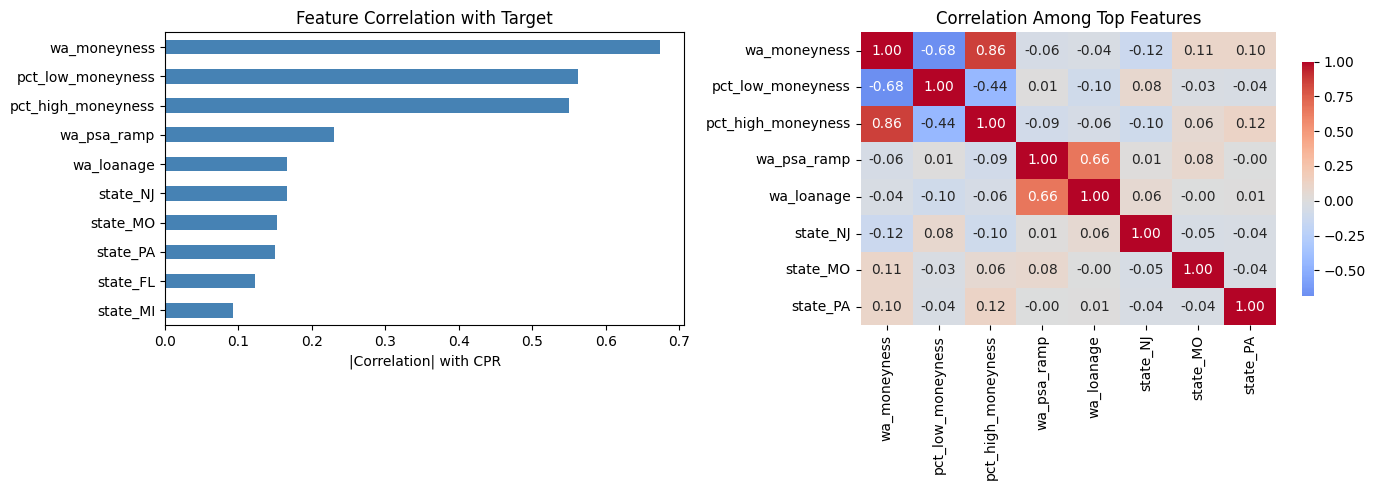


Top features by correlation with CPR:
wa_moneyness         0.6730
pct_low_moneyness    0.5622
pct_high_moneyness   0.5500
wa_psa_ramp          0.2303
wa_loanage           0.1665
state_NJ             0.1662
state_MO             0.1522
state_PA             0.1502
state_FL             0.1228
state_MI             0.0922


In [16]:
# ==== STEP 1: Correlation Analysis ====
corr_with_target = train_dummies.corrwith(y).abs().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of correlations
ax = axes[0]
corr_with_target.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('|Correlation| with CPR')
ax.set_title('Feature Correlation with Target')
ax.invert_yaxis()

# Heatmap of top features
top_feats = corr_with_target[corr_with_target > 0.15].index.tolist()
ax = axes[1]
sns.heatmap(train_dummies[top_feats].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Among Top Features')

plt.tight_layout(); plt.show()

print("\nTop features by correlation with CPR:")
print(corr_with_target.head(10).to_string())

In [17]:
# ==== STEP 2: LassoCV Feature Selection ====
lasso_cv = LassoCV(cv=5, max_iter=10000).fit(X, y)

coef_df = pd.DataFrame({'feature': train_dummies.columns, 'coef': lasso_cv.coef_})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

lasso_selected = coef_df[coef_df['abs_coef'] > 0]['feature'].tolist()

print(f"=== LassoCV Feature Selection ===")
print(f"Optimal alpha: {lasso_cv.alpha_:.5f}")
print(f"R² (in-sample): {lasso_cv.score(X, y):.4f}")
print(f"\nFeatures retained ({len(lasso_selected)} / {len(coef_df)}):")
print(coef_df[coef_df['abs_coef'] > 0][['feature', 'coef']].to_string(index=False))
print(f"\nFeatures dropped ({(coef_df['abs_coef'] == 0).sum()}):")
print(coef_df[coef_df['abs_coef'] == 0]['feature'].tolist())

=== LassoCV Feature Selection ===
Optimal alpha: 0.32129
R² (in-sample): 0.5509

Features retained (9 / 36):
                feature    coef
           wa_moneyness  2.8358
            wa_psa_ramp  1.1121
      pct_low_moneyness -0.8056
               state_MI -0.1824
               state_NJ -0.1822
               state_PA  0.1724
               state_MO  0.0840
             wa_schPrin -0.0444
servicer_JPMorgan Chase  0.0186

Features dropped (27):
['wa_loanage', 'state_WA', 'state_TX', 'state_VA', 'servicer_Flagstar', 'state_WI', 'servicer_Bank of America', 'servicer_PNC Mortgage', 'servicer_PennyMac', 'servicer_Quicken Loans', 'servicer_US Bank', 'state_TN', 'state_NC', 'state_OH', 'state_NY', 'state_MD', 'state_MA', 'state_IN', 'state_IL', 'state_GA', 'state_FL', 'state_CA', 'state_AZ', 'pct_high_moneyness', 'tot_currrpb', 'wa_schrpbNext', 'servicer_Wells Fargo']


In [18]:
# ==== STEP 3: Forward Stepwise Selection ====
all_features = train_dummies.columns.tolist()
selected = []
forward_log = []

print("=== Forward Selection (Ridge α=10, 5-fold CV R²) ===\n")
print(f"{'Step':>4} | {'Added Feature':30s} | {'CV R²':>8} | {'Δ R²':>7}")
print("-" * 60)

for step in range(len(all_features)):
    best_score = -np.inf
    best_feat = None
    for feat in all_features:
        if feat in selected:
            continue
        candidate = selected + [feat]
        X_cand = StandardScaler().fit_transform(train_dummies[candidate])
        score = cross_val_score(Ridge(alpha=10), X_cand, y, cv=5, scoring='r2').mean()
        if score > best_score:
            best_score = score
            best_feat = feat

    prev_score = forward_log[-1][1] if forward_log else 0
    delta = best_score - prev_score
    selected.append(best_feat)
    forward_log.append((best_feat, best_score, delta))
    print(f"{step+1:4d} | {best_feat:30s} | {best_score:8.4f} | {delta:+7.4f}")

    if step > 0 and delta < 0.005:
        print(f"\n  → Stopping: marginal gain ({delta:.4f}) < 0.005")
        break

forward_selected = [f for i, (f, s, d) in enumerate(forward_log) if d >= 0.005 or i == 0]
print(f"\nForward selection kept: {forward_selected}")
print(f"\n--- Both methods agree: {set(forward_selected) & set(lasso_selected[:3])} ---")

=== Forward Selection (Ridge α=10, 5-fold CV R²) ===

Step | Added Feature                  |    CV R² |    Δ R²
------------------------------------------------------------
   1 | wa_moneyness                   |   0.4427 | +0.4427
   2 | wa_psa_ramp                    |   0.5109 | +0.0682
   3 | pct_low_moneyness              |   0.5287 | +0.0178
   4 | state_MI                       |   0.5336 | +0.0049

  → Stopping: marginal gain (0.0049) < 0.005

Forward selection kept: ['wa_moneyness', 'wa_psa_ramp', 'pct_low_moneyness']

--- Both methods agree: {'wa_moneyness', 'wa_psa_ramp', 'pct_low_moneyness'} ---


=== Final Model: OLS on 3 Selected Features (unscaled) ===

Coefficients (natural units):
  wa_moneyness              +3.3712
  wa_psa_ramp               +6.1572
  pct_low_moneyness         -2.4092
  intercept                 +8.1109

Train R²: 0.5415  |  RMSE: 3.717
Test  R²: 0.4001  |  RMSE: 4.201


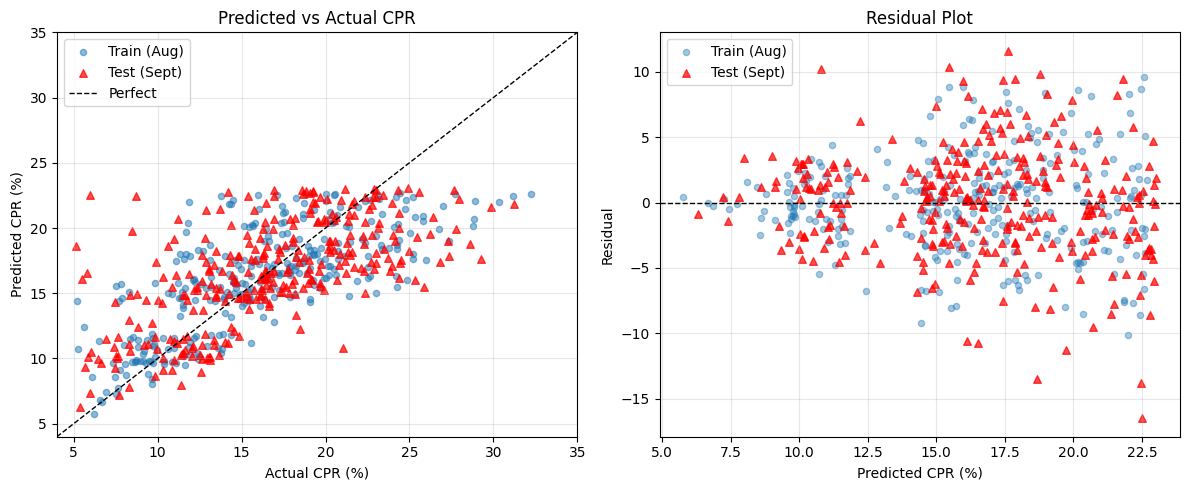

In [19]:
# ==== STEP 4: Final Linear Model (OLS on selected features, unscaled) ====
final_features = ['wa_moneyness', 'wa_psa_ramp', 'pct_low_moneyness']

X_train_final = train_dummies[final_features].values
X_test_final = test_dummies[final_features].values

# Fit OLS (no scaling — coefficients in natural units)
model = LinearRegression().fit(X_train_final, y)
pred_train = model.predict(X_train_final)
pred_test = model.predict(X_test_final)

# --- Print results ---
print("=== Final Model: OLS on 3 Selected Features (unscaled) ===\n")
print("Coefficients (natural units):")
for feat, coef in zip(final_features, model.coef_):
    print(f"  {feat:25s} {coef:+.4f}")
print(f"  {'intercept':25s} {model.intercept_:+.4f}")

train_r2 = r2_score(y, pred_train)
test_r2 = r2_score(test_y, pred_test)
train_rmse = mean_squared_error(y, pred_train) ** 0.5
test_rmse = mean_squared_error(test_y, pred_test) ** 0.5
print(f"\nTrain R²: {train_r2:.4f}  |  RMSE: {train_rmse:.3f}")
print(f"Test  R²: {test_r2:.4f}  |  RMSE: {test_rmse:.3f}")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Predicted vs Actual
ax = axes[0]
ax.scatter(y, pred_train, alpha=0.5, s=20, label='Train (Aug)')
ax.scatter(test_y, pred_test, alpha=0.7, s=30, marker='^', color='red', label='Test (Sept)')
lims = [4, 35]
ax.plot(lims, lims, 'k--', lw=1, label='Perfect')
ax.set_xlabel('Actual CPR (%)'); ax.set_ylabel('Predicted CPR (%)')
ax.set_title('Predicted vs Actual CPR'); ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(lims); ax.set_ylim(lims)

# Plot 2: Residuals
ax = axes[1]
ax.scatter(pred_train, y - pred_train, alpha=0.4, s=20, label='Train (Aug)')
ax.scatter(pred_test, test_y.values - pred_test, alpha=0.7, s=30, marker='^', color='red', label='Test (Sept)')
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Predicted CPR (%)'); ax.set_ylabel('Residual')
ax.set_title('Residual Plot'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Part II Discussion

**Feature Selection Summary.** Three independent methods — correlation filtering, LassoCV, and forward stepwise — all converge on the same 3 features:

| Feature | Role | Economic logic |
|---|---|---|
| `wa_moneyness` | Refi incentive | Higher coupon vs market → stronger motivation to refinance (Q6) |
| `wa_psa_ramp` | Seasoning | min(loanage, 30)/30 captures the non-linear ramp-up in prepayments (Q5) |
| `pct_low_moneyness` | OTM drag | Fraction of borrowers with no refi incentive — anchors the pool's CPR lower |

**Why OLS for the final model.** With only 3 orthogonal features and no multicollinearity, regularization (Ridge/Lasso) doesn't improve predictions — all models give identical R². OLS provides unbiased, interpretable coefficients.

**Limitations.**

- Test R² < Train R² (expected: Aug → Sept shift in prepayment regime)
- Remaining ~50% unexplained variance is idiosyncratic (which specific borrowers prepay this month)
- With more history: add lagged CPR, burnout indicators, seasonality, and rate-path features